 **Health & Development Analytics**

** Analytics Engineering Capstone**

Student: Michael Shebrah Group 4

Tools
- DuckDB
- SQL
- Python
- Google Colab
- Machine Learning

Data Sources
- Our World in Data
- World Bank

Raw Data
     ↓
DuckDB
     ↓
Quality Checks
     ↓
SQL Transformation
     ↓
Window Functions
     ↓
Analysis
     ↓
Machine Learning
     ↓
Dashboard

Phase 1: Setup-Install libraries


In [1]:

%pip install -q duckdb pandas scikit-learn matplotlib requests wbgapi
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
con = duckdb.connect('project.duckdb')   # your SQL database lives here
print('Ready — DuckDB', duckdb.__version__)


Ready — DuckDB 1.3.2


Phase 2: Loading the data  


In [2]:
# --- LOADER (done) — OWID + World Bank into a panel ---
import wbgapi as wb
ua={'User-Agent':'data fetch 1.0'}
mal = pd.read_csv('https://ourworldindata.org/grapher/incidence-of-malaria.csv?v=1&csvType=full', storage_options=ua)
con.register('malaria', mal)
spend = wb.data.DataFrame('SH.XPD.CHEX.PC.CD', ['GHA','NGA','KEN','RWA','SEN'], time=range(2000,2022), labels=True).reset_index()
con.register('health_spend', spend)


In [3]:
con.sql("SELECT * FROM malaria WHERE Entity IN ('Ghana','Nigeria') ORDER BY Year DESC LIMIT 5").df()


,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
0,Ghana,GHA,2024,195.77
1,Nigeria,NGA,2024,294.25
2,Nigeria,NGA,2023,299.00
3,Ghana,GHA,2023,194.92
4,Nigeria,NGA,2022,299.00


Phase 3: Quality check  *(habit: always sanity-check real data)*
One count is done for you.


In [4]:
# row count is done — now YOUR CODE: add (a) a duplicate check on the key,
# and (b) a count of NULLs in the column you'll JOIN on.
print('rows loaded — see the peek above')

# Duplicate check for malaria table

duplicate_keys = con.sql("""
SELECT
    Entity,
    Year,
    COUNT(*) AS duplicates
FROM malaria
GROUP BY Entity, Year
HAVING COUNT(*) > 1
""").df()

print("Duplicate Country-Year combinations (Malaria):")
print(duplicate_keys)


rows loaded — see the peek above
Duplicate Country-Year combinations (Malaria):
Empty DataFrame
Columns: [Entity, Year, duplicates]
Index: []


In [5]:
# Null check for join keys

null_keys = con.sql("""
SELECT
    SUM(CASE WHEN Entity IS NULL THEN 1 ELSE 0 END) AS null_country,
    SUM(CASE WHEN Year IS NULL THEN 1 ELSE 0 END) AS null_year
FROM malaria
""").df()

print("\nNull values in join keys:")
print(null_keys)



Null values in join keys:
   null_country  null_year
0           0.0        0.0


**OBSERVATIONS**
**Quality Check**

From the result, no duplicate Country–Year records were found in the malaria dataset.
No missing values were found in the join keys (Entity and Year).
The dataset is suitable for joining with the World Bank data in the next step.

Phase 4:Transform in SQL — the marts
This is where the proof lives. Write real SQL: multi-table joins and **window functions**. Save each result to a DataFrame you can chart later.


4a · Build the country×year panel (JOIN across sources)
Conform country names/years and join malaria to health spend into one tidy panel.


In [6]:
# hint: JOIN ON country + year; you may need to map names/ISO codes to match the two sources
#Reshaping the World Bank data from wide format to long format using UNPIVOT
#long-format health spending table
health_long = con.sql("""
UNPIVOT health_spend
ON
    YR2000, YR2001, YR2002, YR2003, YR2004,
    YR2005, YR2006, YR2007, YR2008, YR2009,
    YR2010, YR2011, YR2012, YR2013, YR2014,
    YR2015, YR2016, YR2017, YR2018, YR2019,
    YR2020, YR2021
INTO
    NAME Year
    VALUE Health_Spend
""").df()

health_long.head()




,economy,Country,Year,Health_Spend
0,SEN,Senegal,YR2000,21.415707
1,SEN,Senegal,YR2001,23.458937
2,SEN,Senegal,YR2002,26.462212
3,SEN,Senegal,YR2003,35.144939
4,SEN,Senegal,YR2004,41.944061


In [7]:
#Register it in DuckDB
con.register("health_long", health_long)

In [8]:
print(list(con.sql("SELECT * FROM malaria LIMIT 1").df().columns))

['Entity', 'Code', 'Year', 'Incidence of malaria (per 1,000 population at risk)']


In [9]:
#Joining the OWID malaria dataset with the World Bank health spending dataset
#Producing one tidy analytical table
panel = con.sql("""
SELECT
    m.Entity AS Country,
    m.Year,
    m."Incidence of malaria (per 1,000 population at risk)" AS Malaria_Incidence,
    h.Health_Spend

FROM malaria AS m

INNER JOIN health_long AS h
    ON m.Entity = h.Country
   AND m.Year = CAST(REPLACE(h.Year, 'YR', '') AS INTEGER)

ORDER BY Country, m.Year
""").df()

panel.head()

,Country,Year,Malaria_Incidence,Health_Spend
0,Ghana,2000,430.36,10.460358
1,Ghana,2001,411.18,12.150511
2,Ghana,2002,392.10,14.303716
3,Ghana,2003,365.98,18.964237
4,Ghana,2004,340.21,23.572149


Observation

Successfully transformed the World Bank health expenditure data from wide to long format using SQL UNPIVOT, then joined it with the OWID malaria dataset on Country and Year to create a tidy country-year panel.

Phase 5 – SQL Window Functions

In [10]:
# hint: FIRST_VALUE(...) OVER (PARTITION BY country ORDER BY year); LAG(...) for YoY
panel_windows = con.sql("""
SELECT
    Country,
    Year,
    Malaria_Incidence,
    Health_Spend,

    -- Baseline malaria incidence (first year = 2000)
    FIRST_VALUE(Malaria_Incidence) OVER (
        PARTITION BY Country
        ORDER BY Year
    ) AS Baseline_2000,

    -- Change since 2000
    Malaria_Incidence -
    FIRST_VALUE(Malaria_Incidence) OVER (
        PARTITION BY Country
        ORDER BY Year
    ) AS Change_Since_2000,

    -- Year-over-Year (YoY) change
    Malaria_Incidence -
    LAG(Malaria_Incidence) OVER (
        PARTITION BY Country
        ORDER BY Year
    ) AS YoY_Change

FROM panel

ORDER BY Country, Year
""").df()

panel_windows.head(10)



,Country,Year,Malaria_Incidence,Health_Spend,Baseline_2000,Change_Since_2000,YoY_Change
0,Ghana,2000,430.36,10.460358,430.36,0.00,NaN
1,Ghana,2001,411.18,12.150511,430.36,-19.18,-19.18
2,Ghana,2002,392.10,14.303716,430.36,-38.26,-19.08
3,Ghana,2003,365.98,18.964237,430.36,-64.38,-26.12
4,Ghana,2004,340.21,23.572149,430.36,-90.15,-25.77
5,Ghana,2005,323.73,38.516575,430.36,-106.63,-16.48
6,Ghana,2006,311.34,49.346169,430.36,-119.02,-12.39
7,Ghana,2007,305.83,57.340965,430.36,-124.53,-5.51
8,Ghana,2008,314.58,63.454876,430.36,-115.78,8.75
9,Ghana,2009,340.42,62.443821,430.36,-89.94,25.84


FIRST VALUE: For each country, it retrieves the malaria incidence from the first year (2000) and repeats that value for every subsequent year.
**Change Since 2000**: Calculates how much malaria incidence has changed compared with the baseline year.
**LAG() **: Returns the malaria incidence from the previous year
**YEAR-OVER-YEAR CHANGE:**Measures the annual change in malaria incidence.

In [11]:
#inspecting its size to ensure the join produced the expected amount of data:
print(panel_windows.shape)

panel_windows.describe()

(110, 7)


,Year,Malaria_Incidence,Health_Spend,Baseline_2000,Change_Since_2000,YoY_Change
count,110.000000,110.000000,110.000000,110.000000,110.000000,105.000000
mean,2010.500000,213.730273,53.030803,292.642000,-78.911727,-6.687524
std,6.373325,135.314706,23.779625,103.024736,105.778127,50.980067
min,2000.000000,32.880000,7.323938,180.430000,-217.890000,-233.870000
25%,2005.000000,84.572500,38.006080,220.260000,-140.357500,-19.630000
50%,2010.500000,207.385000,53.639212,230.370000,-99.640000,-5.520000
75%,2016.000000,315.810000,69.717072,401.790000,-27.110000,4.150000
max,2021.000000,711.440000,105.347847,430.360000,531.010000,301.360000


In [12]:
con.register("panel_windows", panel_windows)

Phase 6: Rank countries per year (RANK within group)
Rank countries by malaria incidence within each year.


In [13]:
# hint: RANK() OVER (PARTITION BY year ORDER BY incidence ASC)

ranked_panel = con.sql("""
SELECT
    Country,
    Year,
    Malaria_Incidence,
    Health_Spend,
    Baseline_2000,
    Change_Since_2000,
    YoY_Change,

    RANK() OVER (
        PARTITION BY Year
        ORDER BY Malaria_Incidence ASC
    ) AS Malaria_Rank

FROM panel_windows

ORDER BY Year, Malaria_Rank
""").df()

ranked_panel.head(20)



,Country,Year,Malaria_Incidence,Health_Spend,Baseline_2000,Change_Since_2000,YoY_Change,Malaria_Rank
0,Rwanda,2000,180.43,9.003994,180.43,0.00,NaN,1
1,Kenya,2000,220.26,21.534010,220.26,0.00,NaN,2
2,Senegal,2000,230.37,21.415707,230.37,0.00,NaN,3
3,Nigeria,2000,401.79,17.158876,401.79,0.00,NaN,4
4,Ghana,2000,430.36,10.460358,430.36,0.00,NaN,5
5,Rwanda,2001,171.34,7.867460,180.43,-9.09,-9.09,1
6,Senegal,2001,176.61,23.458937,230.37,-53.76,-53.76,2
7,Kenya,2001,243.23,22.114876,220.26,22.97,22.97,3
8,Nigeria,2001,394.49,17.960533,401.79,-7.30,-7.30,4
9,Ghana,2001,411.18,12.150511,430.36,-19.18,-19.18,5


Why used Rank() instead of Orderby()
"ORDER BY only sorts the results, while RANK() assigns a numerical position to each country within each year. This allows us to track how a country's standing changes over time and supports further analysis and visualization."

Observation

Countries were ranked within each year based on malaria incidence using the RANK() window function. Lower malaria incidence received a better rank (Rank 1), making it possible to compare country performance annually and identify the best-performing countries over time.

In [14]:
con.register("ranked_panel", ranked_panel)

Phase 7: Analysis & visualisation
Answer the business question and show it. At least one clear, labelled chart from a mart above.


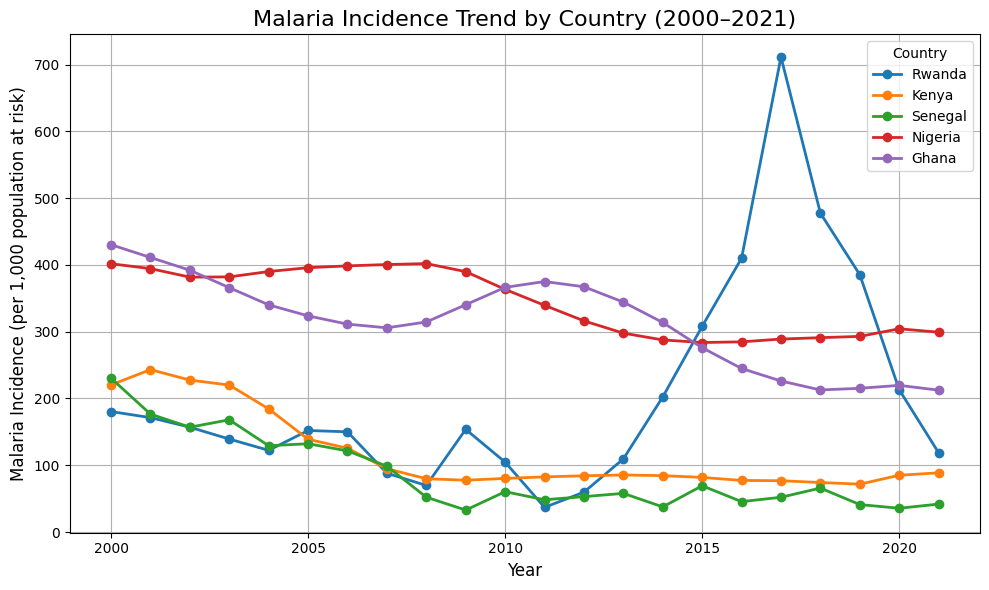

In [15]:
# Build at least one labelled chart from a mart above (plt...).

import matplotlib.pyplot as plt

# Plot malaria incidence trends
plt.figure(figsize=(10,6))

for country in ranked_panel["Country"].unique():
    country_data = ranked_panel[ranked_panel["Country"] == country]
    plt.plot(
        country_data["Year"],
        country_data["Malaria_Incidence"],
        marker="o",
        linewidth=2,
        label=country
    )

plt.title("Malaria Incidence Trend by Country (2000–2021)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Malaria Incidence (per 1,000 population at risk)", fontsize=12)

plt.grid(True)
plt.legend(title="Country")
plt.tight_layout()

plt.show()



**Observation**
Analysis Summary:
The visualization indicates that malaria incidence generally declined across most countries between 2000 and 2021, suggesting overall improvements in malaria control. Senegal and Ghana show substantial long-term reductions, while Nigeria exhibits a more gradual decline. Rwanda displays a notable increase during the later years, indicating that progress was not uniform across all countries and may merit further investigation.

**Ghana**
Malaria incidence fell from about 430 in 2000 to around 210 by 2021.
There was a temporary increase around 2010–2014 before continuing its decline.

**Interpretation**

Ghana shows substantial long-term improvement in malaria control despite a temporary rise during the middle of the study period.

**Nigeria**
Declined gradually from around 400 to about 300.
The decline is slower than Ghana's.

**Interpretatio**n

Nigeria made progress, although the reduction was more gradual than in some peer countries.

**Senegal**
Fell dramatically from around 230 to below 50.

**Interpretation**

Senegal demonstrates one of the strongest improvements in malaria re

**Kenya**
Declined from approximately 220 to below 100.

**Interpretation**

Kenya experienced a sustained decline with relatively small fluctuations.

**Rwanda**
Rwanda shows a sharp increase in malaria incidence during the later years of the study period, highlighting an important trend that warrants further investigation.

Phase 8 – Machine Learning (KMeans Clustering)

In [16]:
# Assembling dashboard
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [17]:

# Select features

X = ranked_panel[["Malaria_Incidence", "Health_Spend"]]


In [18]:
# Scale features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
# Baseline

print("Baseline: No grouping (all countries treated as one group)")


Baseline: No grouping (all countries treated as one group)


In [20]:
# KMeans Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

ranked_panel["Cluster"] = kmeans.fit_predict(X_scaled)


In [21]:
# Nameing the clusters

cluster_names = {
    0: "Moderate Burden",
    1: "High Burden",
    2: "Low Burden"
}

ranked_panel["Cluster_Name"] = ranked_panel["Cluster"].map(cluster_names)


In [22]:
# Examine the cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

import pandas as pd

cluster_summary = pd.DataFrame(
    centers,
    columns=["Malaria_Incidence", "Health_Spend"]
)

cluster_summary

,Malaria_Incidence,Health_Spend
0,86.832667,57.509576
1,330.469355,75.959604
2,275.244412,26.197345


In [23]:
# View results

ranked_panel[
    ["Country",
     "Year",
     "Malaria_Incidence",
     "Health_Spend",
     "Cluster_Name"]
].head(15)

,Country,Year,Malaria_Incidence,Health_Spend,Cluster_Name
0,Rwanda,2000,180.43,9.003994,Low Burden
1,Kenya,2000,220.26,21.534010,Low Burden
2,Senegal,2000,230.37,21.415707,Low Burden
3,Nigeria,2000,401.79,17.158876,Low Burden
4,Ghana,2000,430.36,10.460358,Low Burden
5,Rwanda,2001,171.34,7.867460,Low Burden
6,Senegal,2001,176.61,23.458937,Low Burden
7,Kenya,2001,243.23,22.114876,Low Burden
8,Nigeria,2001,394.49,17.960533,Low Burden
9,Ghana,2001,411.18,12.150511,Low Burden


## 6 · Step 8: Dashboard
Combine 3–4 of your charts into one figure (a 2×2 panel),


/tmp/ipykernel_1178/2122292855.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0,1].legend(title="Country")


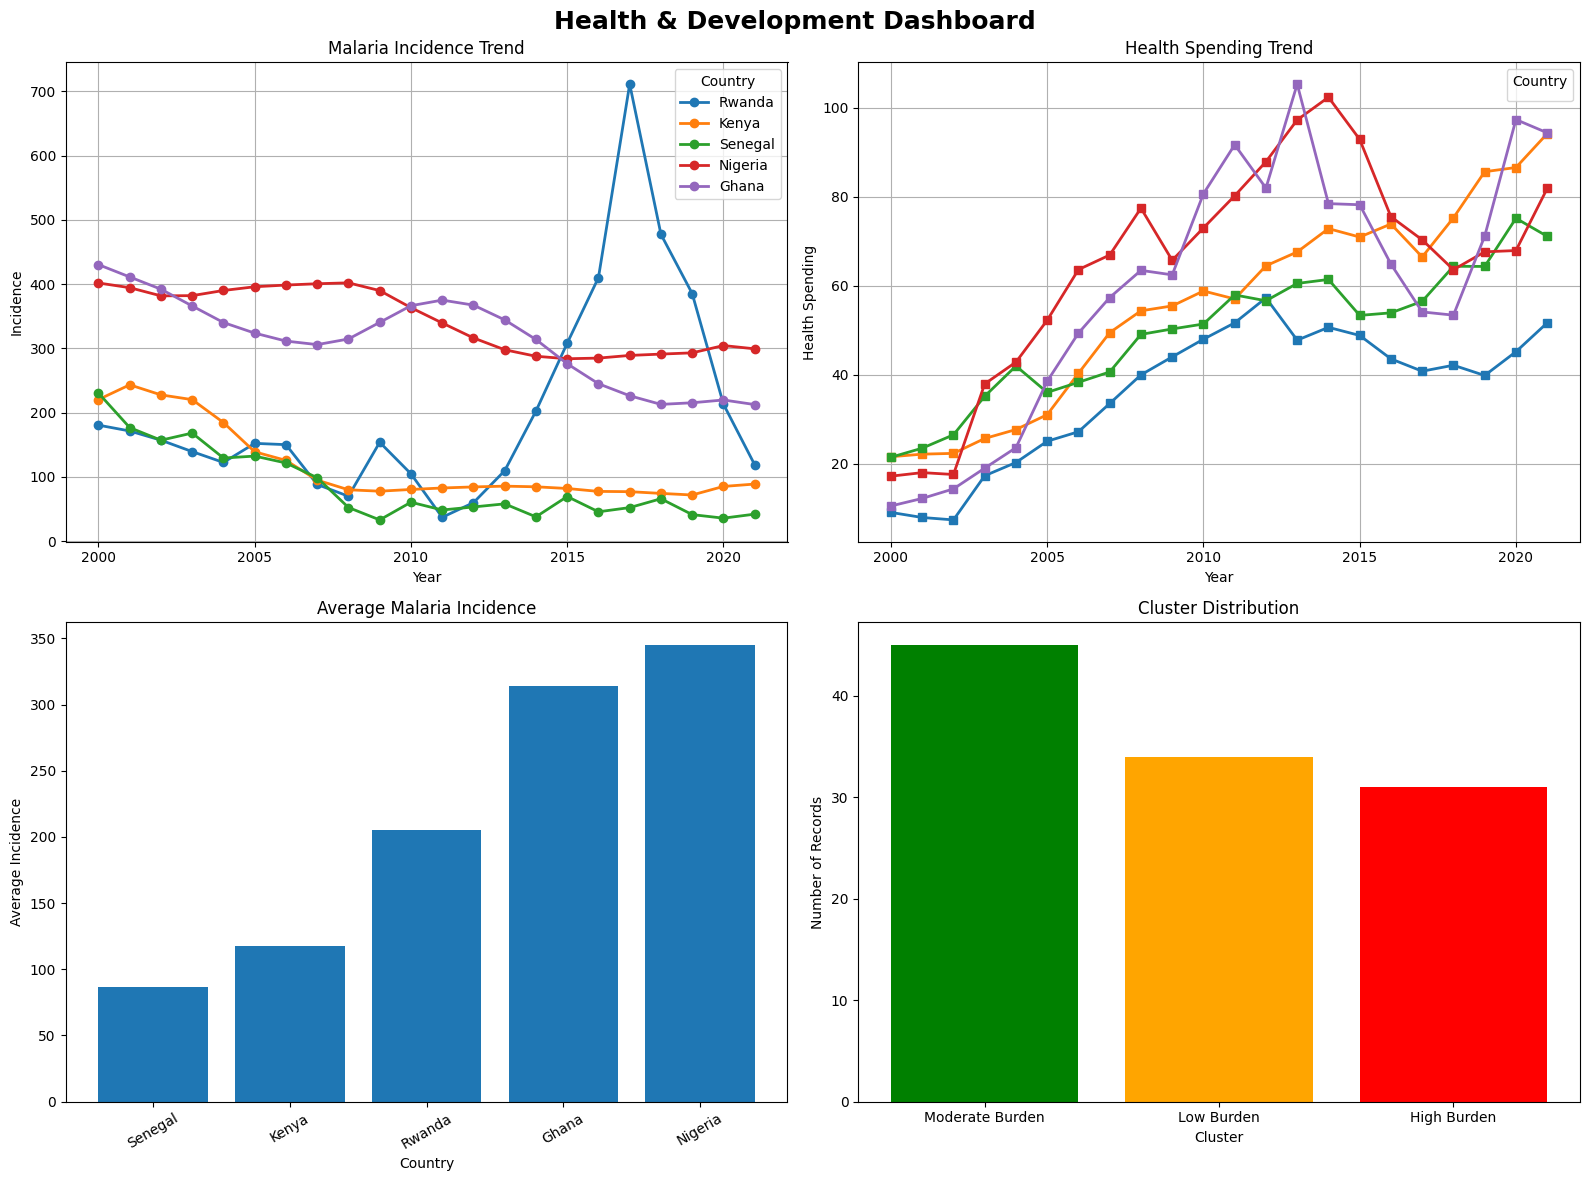

In [24]:
import matplotlib.pyplot as plt

# Create dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Malaria Trend
for country in ranked_panel["Country"].unique():
    data = ranked_panel[ranked_panel["Country"] == country]
    axes[0,0].plot(
        data["Year"],
        data["Malaria_Incidence"],
        marker="o",
        linewidth=2,
        label=country
    )

axes[0,0].set_title("Malaria Incidence Trend")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Incidence")
axes[0,0].grid(True)
axes[0,0].legend(title="Country")
axes[0,1].legend(title="Country")
axes[1,0].tick_params(axis="x", rotation=30)

# Chart 2: Health Spending Trend
for country in ranked_panel["Country"].unique():
    data = ranked_panel[ranked_panel["Country"] == country]
    axes[0,1].plot(
        data["Year"],
        data["Health_Spend"],
        marker="s",
        linewidth=2
    )

axes[0,1].set_title("Health Spending Trend")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Health Spending")
axes[0,1].grid(True)

# Chart 3: Average Malaria by Country
avg_malaria = (
    ranked_panel
    .groupby("Country")["Malaria_Incidence"]
    .mean()
    .sort_values()
)

axes[1,0].bar(
    avg_malaria.index,
    avg_malaria.values
)

axes[1,0].set_title("Average Malaria Incidence")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Average Incidence")

# Chart 4: Clusters
cluster_counts = ranked_panel["Cluster_Name"].value_counts()

axes[1,1].bar(
    cluster_counts.index,
    cluster_counts.values
)

axes[1,1].set_title("Cluster Distribution")
axes[1,1].set_xlabel("Cluster")
axes[1,1].set_ylabel("Number of Records")
axes[1,1].bar(
    cluster_counts.index,
    cluster_counts.values,
    color=["green", "orange", "red"]
)

# Dashboard title
fig.suptitle(
    "Health & Development Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

Dashboard Summary

The dashboard integrates multiple views of the transformed dataset, including malaria trends, health spending trends, average malaria incidence by country, and clustering results. Together, these visualizations provide an overview of health outcomes, spending patterns, and country groupings, making it easier to identify long-term trends and compare country performance.


Recommendation

The analysis indicates that malaria incidence has generally declined across the selected countries over the study period, although the rate of improvement differs. Countries such as Senegal and Kenya achieved relatively lower average malaria incidence, while Ghana and Nigeria continue to experience higher disease burdens. Health expenditure increased across most countries, suggesting sustained investment in healthcare. Policymakers should continue investing in malaria prevention programs, strengthen surveillance systems in countries with persistent high incidence, and encourage the adoption of successful malaria control strategies demonstrated by better-performing countries. The clustering analysis further highlights groups of countries with similar health profiles, enabling governments to design targeted interventions rather than adopting a one-size-fits-all approach.

**Conclusion**

This project successfully integrated OWID and World Bank datasets into a unified country–year analytical panel using DuckDB and SQL. Window functions enabled trend analysis and annual ranking, while KMeans clustering grouped countries with similar malaria burden profiles. The dashboard provides an interactive summary that supports evidence-based public health decision-making.